In [53]:
import pandas as pd
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [54]:
cat_df = pd.read_csv("cat_breeds.csv")
cat_df

,name,length,origin,min_life_expectancy,max_life_expectancy,min_weight,max_weight,family_friendly,shedding,general_health,playfulness,children_friendly,grooming,intelligence,other_pets_friendly
0,Abyssinian,12 to 16 inches,Southeast Asia,9.0,15.0,6.0,10.0,3,3,2,5,5,3,5,5
1,Aegean,Medium,Greece,9.0,10.0,7.0,10.0,5,3,4,4,5,4,4,3
2,American Bobtail,Medium,United States and Canada,11.0,15.0,8.0,13.0,4,4,4,4,4,3,4,4
3,American Shorthair,12 to 15 inches,United States,15.0,20.0,7.0,12.0,3,3,4,2,4,4,4,3
4,American Wirehair,Medium to large,United States,14.0,18.0,8.0,15.0,4,3,5,3,4,5,4,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,Toyger,Medium,United States,10.0,15.0,7.0,15.0,5,1,3,4,4,4,4,4
58,Turkish Angora,Medium,"Ankara, Turkey",12.0,18.0,5.0,9.0,5,2,3,5,3,4,4,3
59,Turkish Van,14 to 17 inches,"Lake Van, Turkey",12.0,17.0,10.0,18.0,3,2,4,4,3,4,5,3
60,Ukrainian Levkoy,Medium,Russia,9.0,15.0,8.0,12.0,5,1,3,4,5,2,5,4


In [55]:
features = [
    'min_life_expectancy', 'max_life_expectancy',
    'min_weight', 'max_weight',
    'family_friendly', 'shedding', 'general_health',
    'playfulness', 'children_friendly', 'grooming',
    'intelligence', 'other_pets_friendly'
]

In [56]:
X_raw = cat_df[features].copy()
names  = cat_df['name'].tolist()

scaler = StandardScaler()
df = scaler.fit_transform(X_raw)

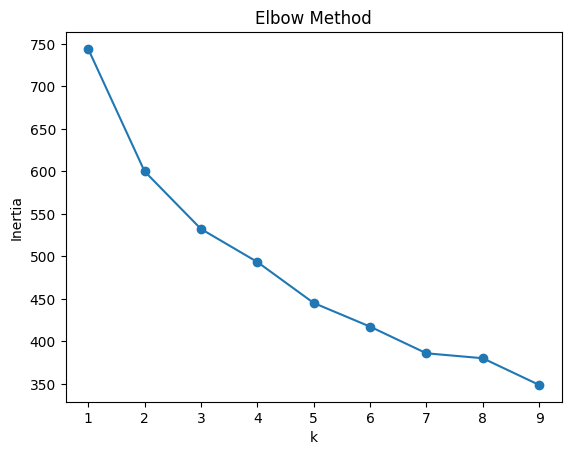

In [57]:
inertia = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()



In [58]:
K = 4
km_final = KMeans(n_clusters=K, random_state=42, n_init=10)
cat_df['cluster'] = km_final.fit_predict(df)

CLUSTER_NAMES = {
    0: 'The Lap Cat',
    1: 'The Wild Heart',
    2: 'The Social Butterfly',
    3: 'The Low-Key Companion'
}
cat_df['cluster_name'] = cat_df['cluster'].map(CLUSTER_NAMES)
cat_df.groupby('cluster_name')[features].mean()


,min_life_expectancy,max_life_expectancy,min_weight,max_weight,family_friendly,shedding,general_health,playfulness,children_friendly,grooming,intelligence,other_pets_friendly
cluster_name,,,,,,,,,,,,
The Lap Cat,10.290323,14.870968,6.338710,11.516129,4.645161,1.935484,2.870968,4.322581,4.548387,3.451613,4.161290,4.096774
The Low-Key Companion,12.000000,14.000000,15.000000,30.000000,4.000000,1.000000,4.000000,4.000000,1.000000,5.000000,5.000000,4.000000
The Social Butterfly,10.933333,15.666667,8.133333,15.866667,4.066667,3.800000,3.466667,3.666667,3.866667,2.266667,4.000000,3.533333
The Wild Heart,13.733333,18.466667,8.000000,15.266667,3.866667,2.333333,4.000000,3.666667,4.133333,4.466667,4.133333,3.666667


In [59]:
print("\n" + "="*60)
print("CLUSTER SUMMARIES")
print("="*60)
for cid, cname in CLUSTER_NAMES.items():
    subset = cat_df[cat_df['cluster'] == cid]
    print(f"\n🐱 Cluster {cid}: {cname} (n={len(subset)})")
    print(f"   Breeds: {', '.join(subset['name'].tolist())}")
    print(f"   Avg playfulness:      {subset['playfulness'].mean():.2f}")
    print(f"   Avg family_friendly:  {subset['family_friendly'].mean():.2f}")
    print(f"   Avg shedding:         {subset['shedding'].mean():.2f}")
    print(f"   Avg grooming:         {subset['grooming'].mean():.2f}")
    print(f"   Avg intelligence:     {subset['intelligence'].mean():.2f}")
    print(f"   Avg lifespan:         {((subset['min_life_expectancy']+subset['max_life_expectancy'])/2).mean():.1f} yrs")
    print(f"   Avg weight:           {((subset['min_weight']+subset['max_weight'])/2).mean():.1f} lbs")


CLUSTER SUMMARIES

🐱 Cluster 0: The Lap Cat (n=31)
   Breeds: Abyssinian, Aegean, Asian, Bambino, Bengal Cats, Birman, Burmese, Burmilla, Colorpoint Shorthair, Cornish Rex, Cyprus, Devon Rex, Donskoy, Foldex, German Rex, Japanese Bobtail, Javanese, Khao Manee, Oriental Bicolor, Peterbald, Scottish Fold, Serengeti, Siamese Cat, Singapura, Sokoke, Somali, Sphynx, Tonkinese, Toyger, Turkish Angora, Ukrainian Levkoy
   Avg playfulness:      4.32
   Avg family_friendly:  4.65
   Avg shedding:         1.94
   Avg grooming:         3.45
   Avg intelligence:     4.16
   Avg lifespan:         12.6 yrs
   Avg weight:           8.9 lbs

🐱 Cluster 1: The Wild Heart (n=15)
   Breeds: American Shorthair, American Wirehair, Arabian Mau, Australian Mist, Bombay, Brazilian Shorthair, British Shorthair, California Spangled, European Shorthair, Kurilian Bobtail, Mekong Bobtail, Savannah, Snowshoe, American Shorthair, Turkish Van
   Avg playfulness:      3.67
   Avg family_friendly:  3.87
   Avg shedding